In [51]:
import numpy as np
import pandas as pd
import seaborn  as sns
import matplotlib.pyplot as plt


In [52]:
df=pd.read_csv('train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [53]:
df.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [54]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
LotFrontage,259
Alley,1369
MasVnrType,872
MasVnrArea,8
BsmtQual,37
BsmtCond,37
BsmtExposure,38
BsmtFinType1,37
BsmtFinType2,38
Electrical,1


In [55]:
df.shape

(1460, 81)

In [56]:
df.duplicated().sum()

np.int64(0)

In [57]:
#drop high null value column
df=df.drop(columns=[
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence"
])

In [58]:
#categorical columns null values fill
cat_cols = [
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "MasVnrType"
]

df[cat_cols] = df[cat_cols].fillna("None")

In [59]:
#Numeric columns null values fill
df["LotFrontage"] = df["LotFrontage"].fillna(
    df["LotFrontage"].median()
)

df["MasVnrArea"] = df["MasVnrArea"].fillna(
    df["MasVnrArea"].median()
)

df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)

In [60]:
df['Electrical']=df['Electrical'].fillna(df['Electrical'].mode()[0])

In [61]:
#after removing all null values  see null value  in dataset
df.isnull().sum()[df.isnull().sum() > 0]

,0


### Identify Numerical Columns for Box Plots

In [62]:
numerical_cols = df.select_dtypes(include=np.number).columns
print(f"Found {len(numerical_cols)} numerical columns.")

Found 38 numerical columns.


### Generate Box Plots for Numerical Columns

I will create a box plot for each numerical column to visualize the distribution and identify potential outliers. Due to the number of columns, these will be displayed in individual plots.

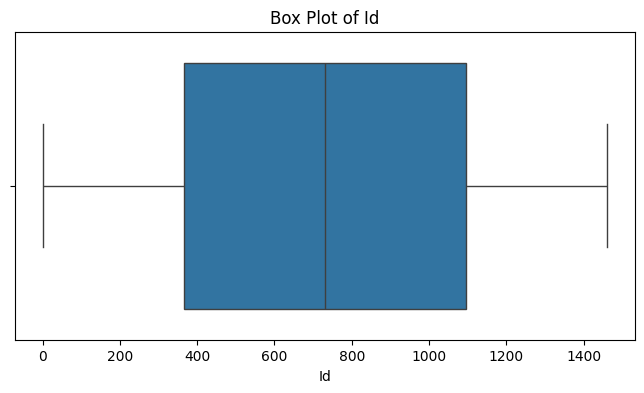

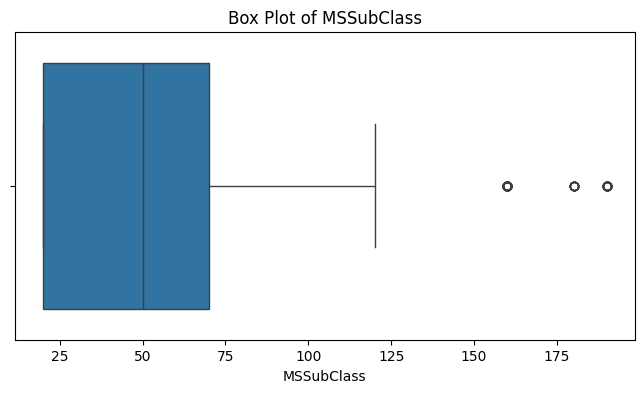

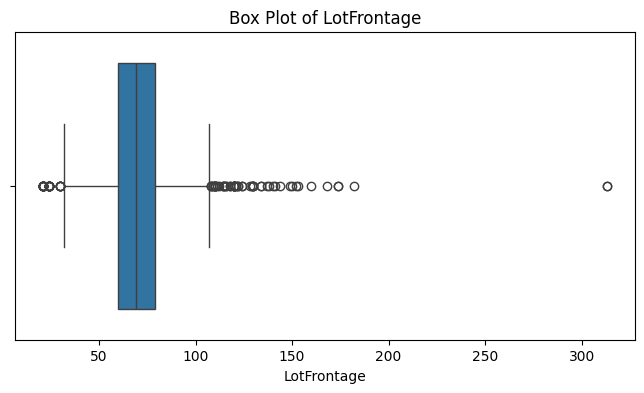

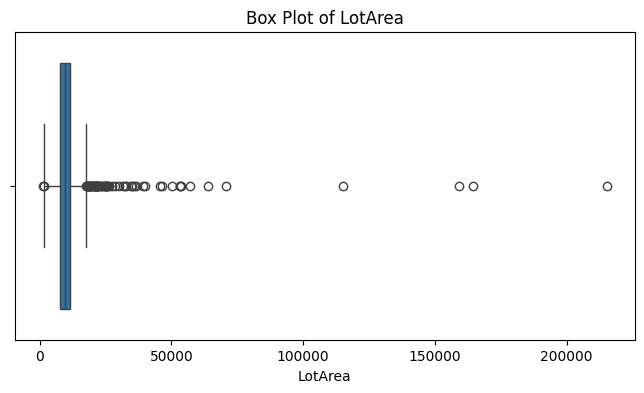

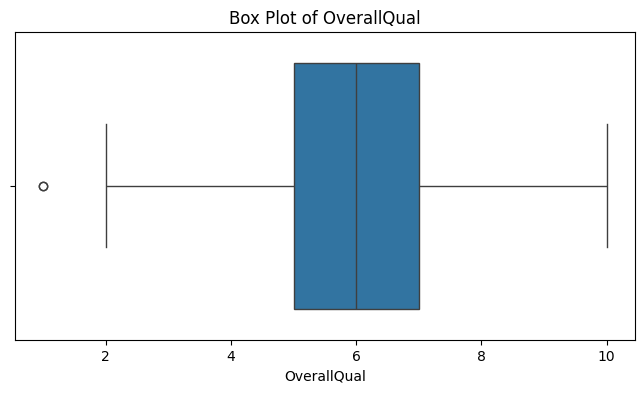

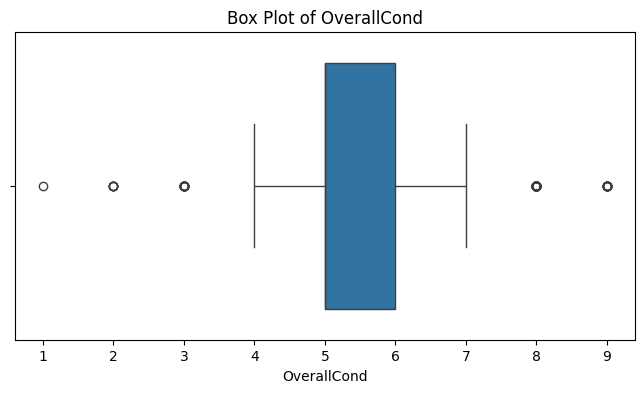

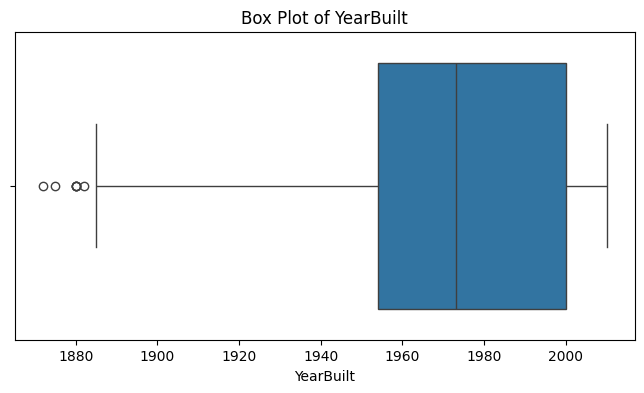

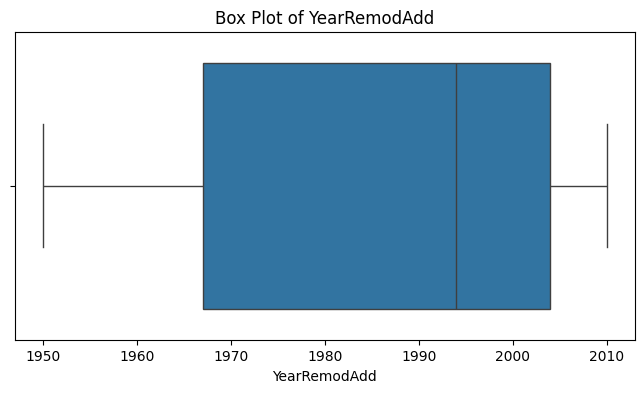

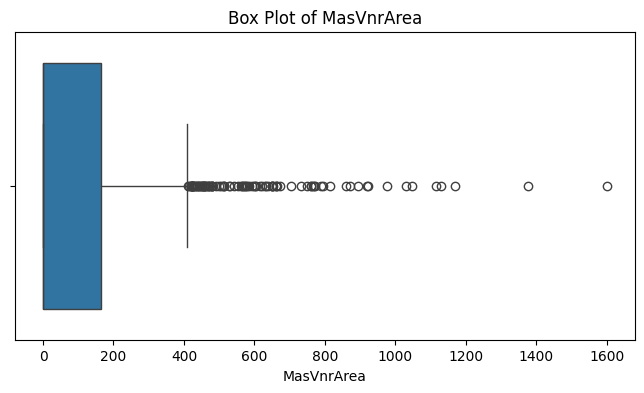

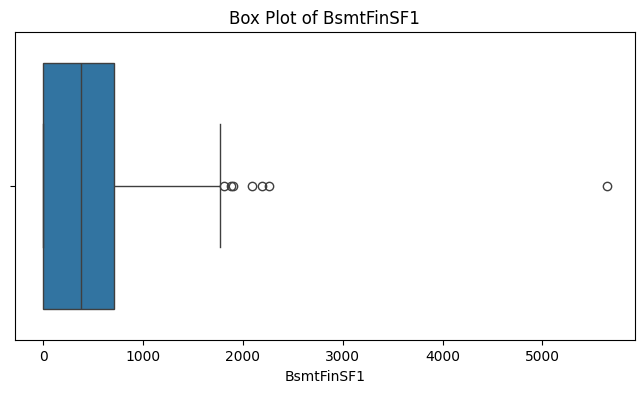

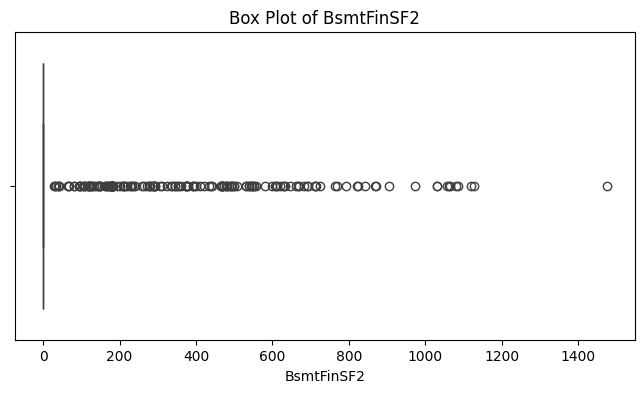

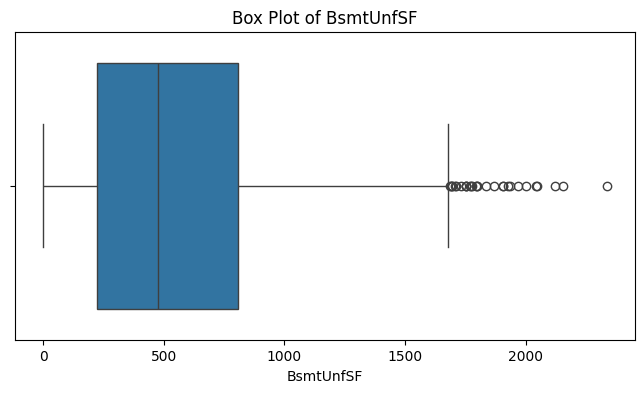

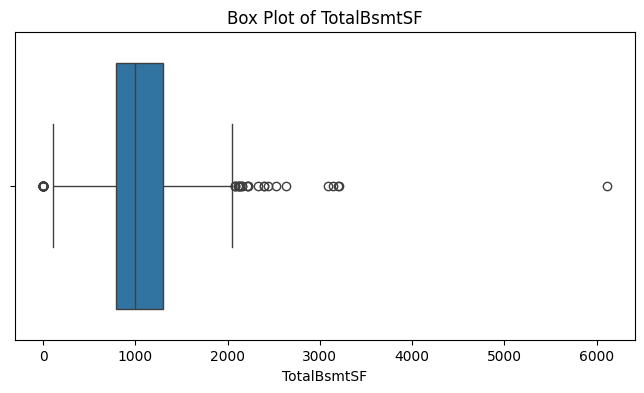

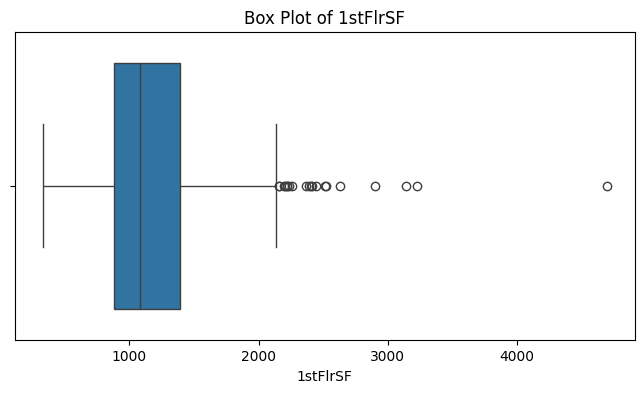

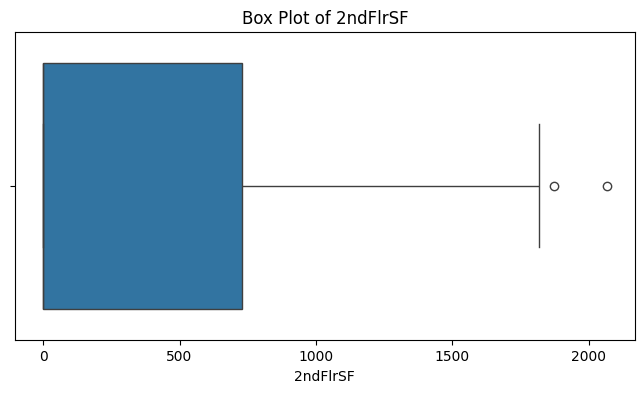

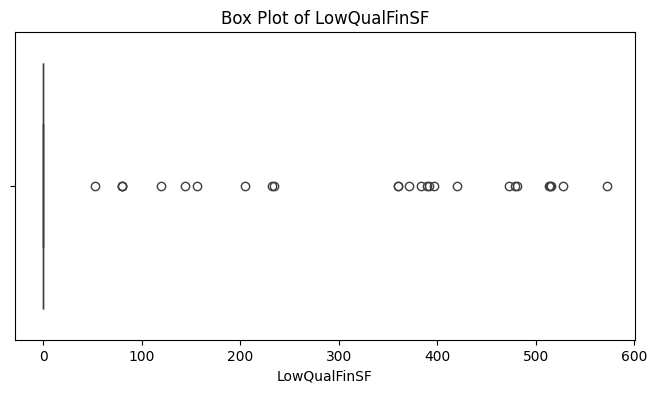

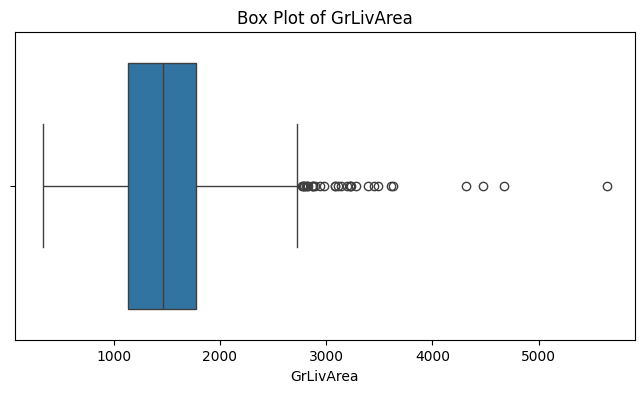

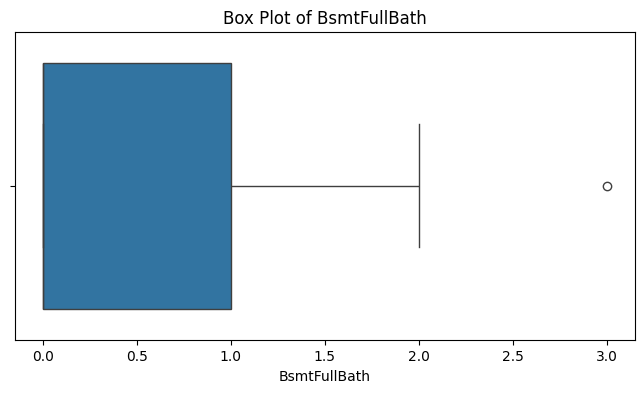

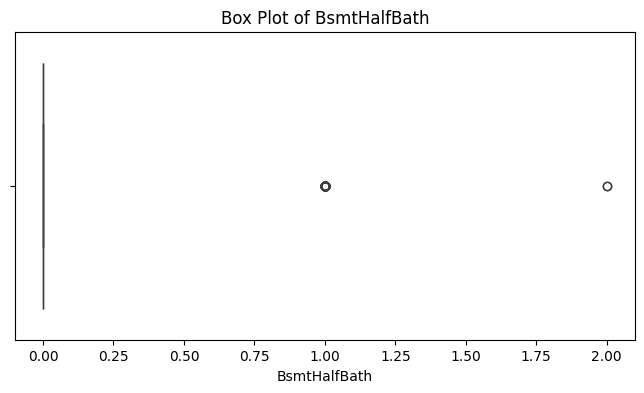

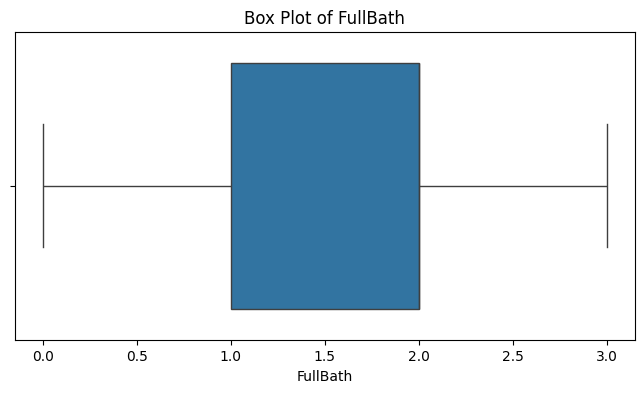

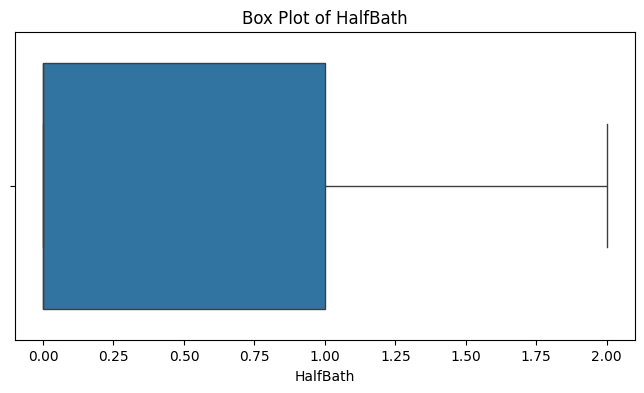

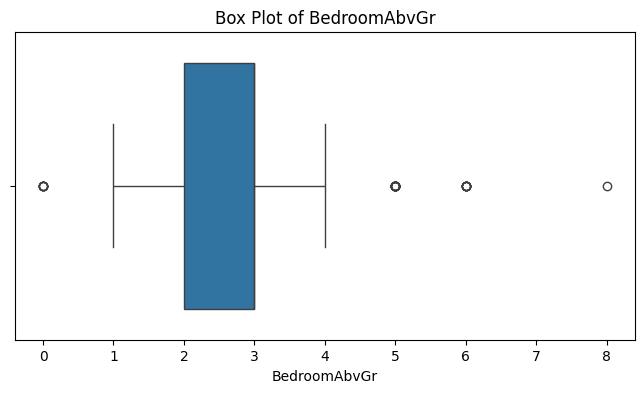

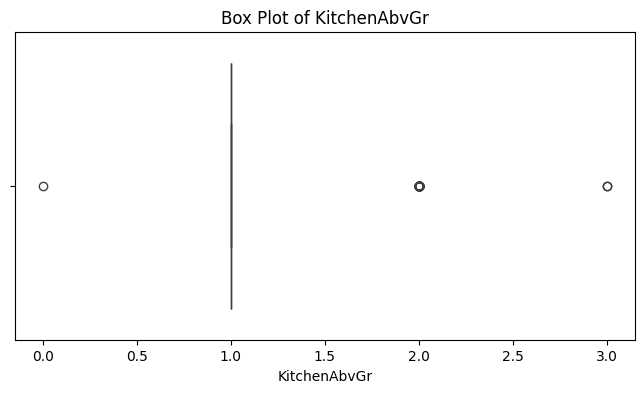

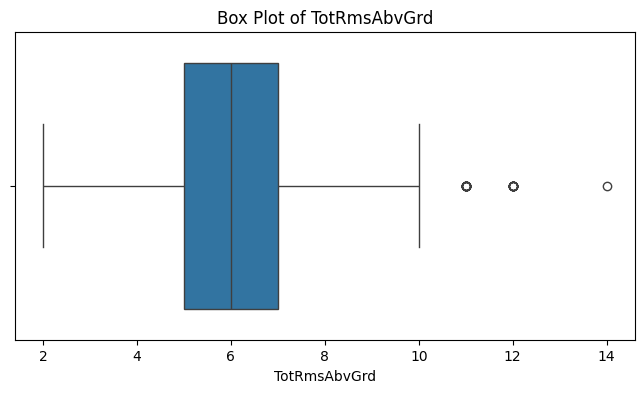

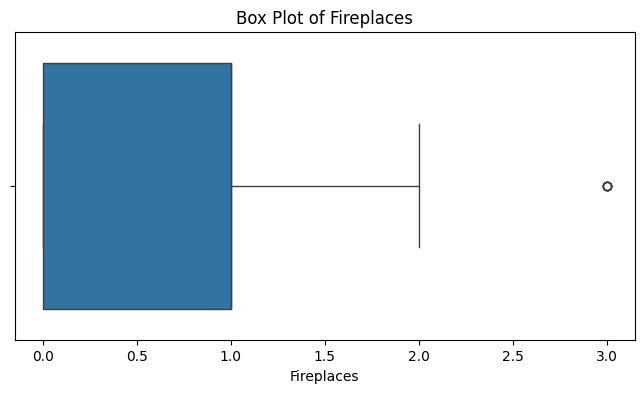

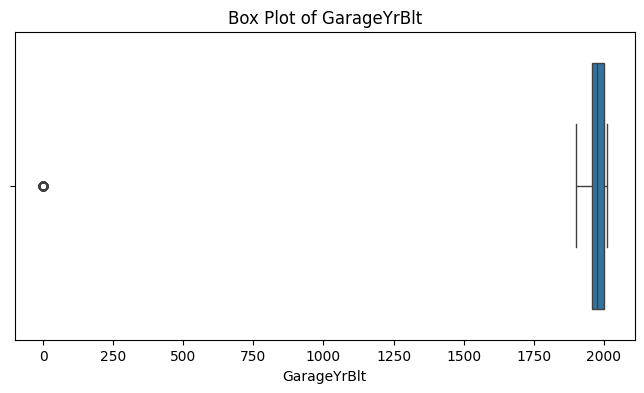

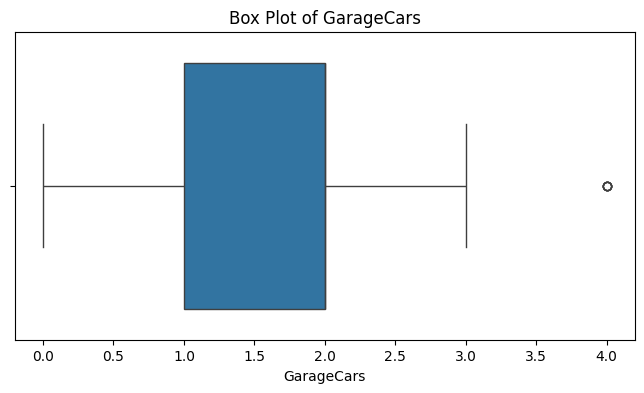

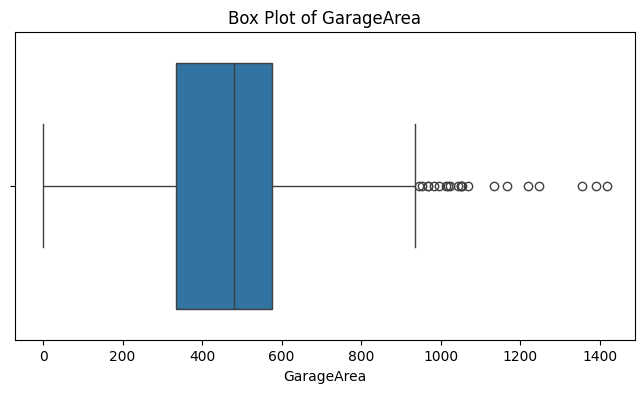

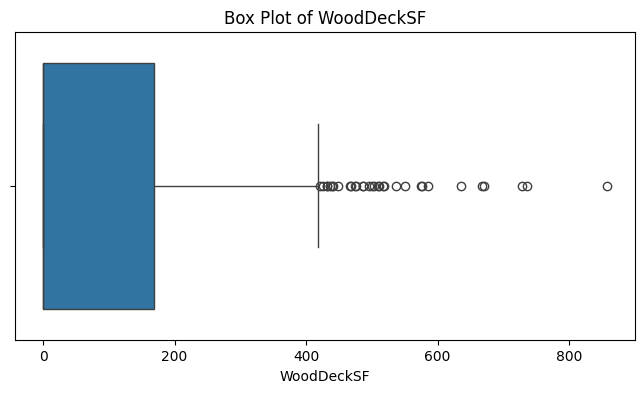

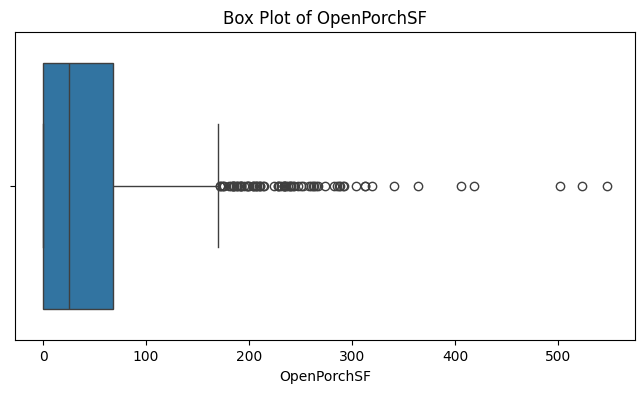

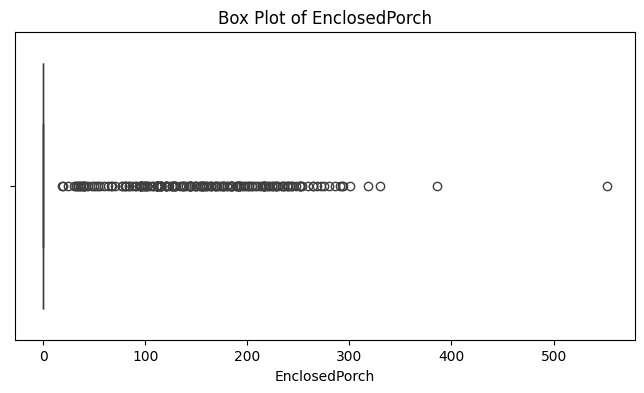

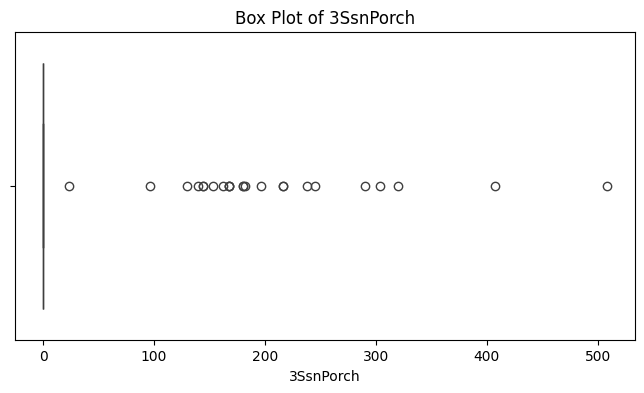

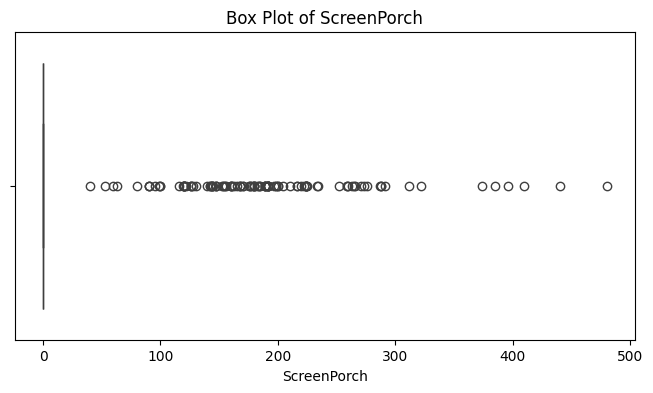

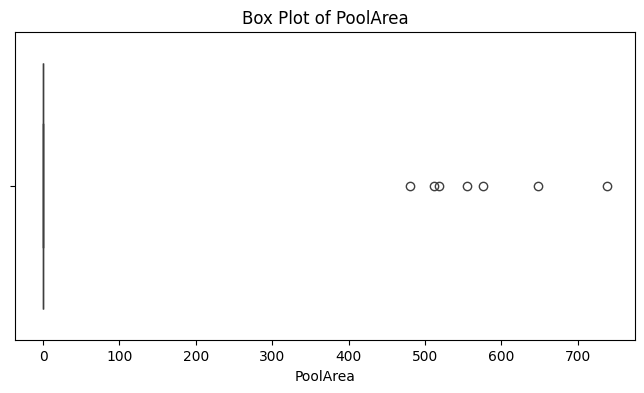

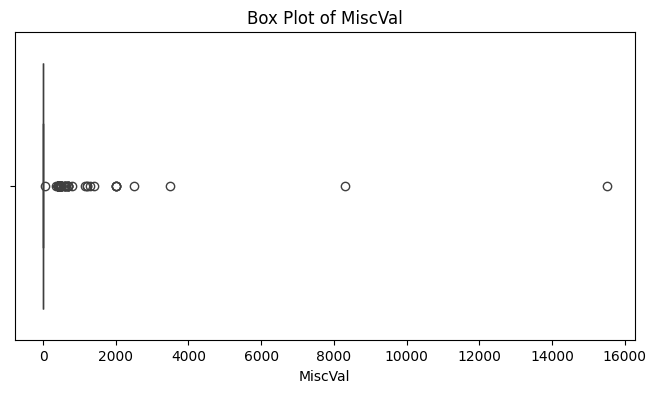

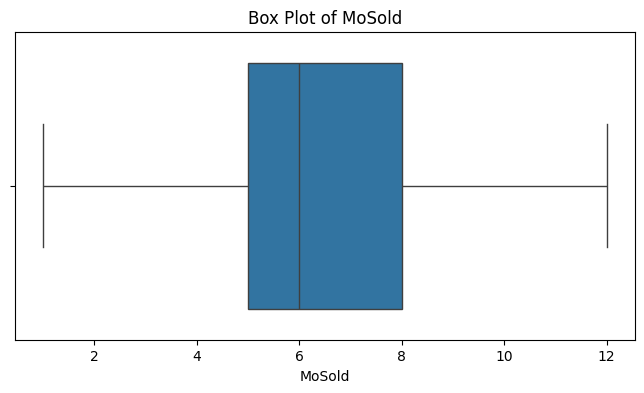

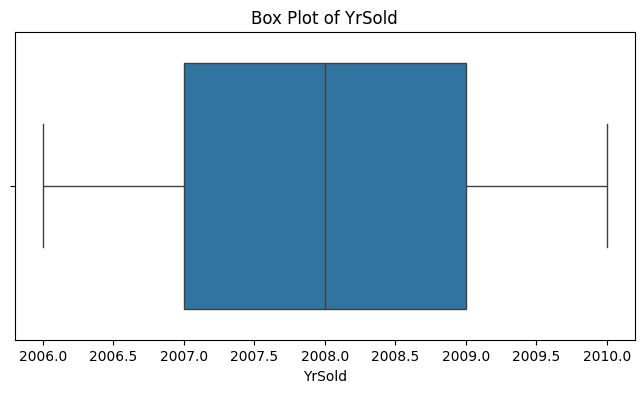

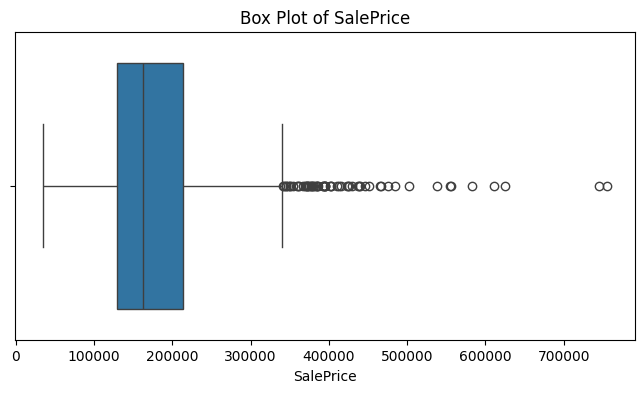

In [63]:
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)
    plt.show()

## Feature Selection: Identifying the Best 15 Features

To select the most relevant features for predicting `SalePrice`, we will use `SelectKBest` with `f_regression` from `sklearn.feature_selection`. This method helps evaluate the linear relationship between each feature and the target variable.

First, we'll prepare the dataset by:
1.  Separating the target variable (`SalePrice`) from the features.
2.  Dropping the non-predictive 'Id' column.
3.  Converting categorical features into numerical format using `LabelEncoder` so they can be processed by `f_regression`.

In [71]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, f_regression

# Separate target variable 'y' from features 'X'
X = df.drop(columns=['Id', 'SalePrice'])
y = df['SalePrice']

# Identify categorical columns for encoding
categorical_cols = X.select_dtypes(include='object').columns

# Apply Label Encoding to categorical columns
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Verify dtypes after encoding - all should be numerical now
print("Data types after Label Encoding:")
display(X[categorical_cols].dtypes)

# Initialize SelectKBest with f_regression and select top 15 features
k_best_features = SelectKBest(score_func=f_regression, k=15)
fit = k_best_features.fit(X, y)

# Get scores and feature names
df_scores = pd.DataFrame({'Feature': X.columns, 'Score': fit.scores_})
df_scores = df_scores.sort_values(by='Score', ascending=False)

# Select the top 15 features
top_15_features = df_scores.head(15)['Feature'].tolist()

print("\nTop 15 Features based on f_regression scores:")
for feature in top_15_features:
    print(feature)

Data types after Label Encoding:


,0
MSZoning,int64
Street,int64
LotShape,int64
LandContour,int64
Utilities,int64
LotConfig,int64
LandSlope,int64
Neighborhood,int64
Condition1,int64
Condition2,int64



Top 15 Features based on f_regression scores:
OverallQual
GrLivArea
GarageCars
ExterQual
GarageArea
TotalBsmtSF
1stFlrSF
BsmtQual
KitchenQual
FullBath
TotRmsAbvGrd
YearBuilt
YearRemodAdd
MasVnrArea
Fireplaces


In [73]:
# Select the top 15 features from the already encoded X DataFrame
x = X[top_15_features]
y = df['SalePrice']

In [74]:
from sklearn.model_selection import train_test_split
X_train ,X_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=42)

In [75]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train,y_train)



LinearRegression()

In [79]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
import numpy as np

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# R2 scores
print("Training R2:", r2_score(y_train, y_train_pred))
print("Testing R2:", r2_score(y_test, y_test_pred))

# Testing metrics
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("MSE:", mean_squared_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))

Training R2: 0.7876567523229895
Testing R2: 0.8144968841877842
MAE: 23421.491149748592
MSE: 1361850971.7868354
RMSE: 36903.265055911186
